In [86]:
import mesa
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from mesa.datacollection import DataCollector
import itertools
from io import StringIO

In [87]:
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')
except:
    raise FileNotFoundError("The demographic distribution file 'demog_distrib.csv' was not found. Please ensure it is in the correct directory.")
    multiline_csv = """
        region,gender_m,gender_f,age_<19,age_20_29,age_30_39,age_40_49,age_50_59,age_60_69,age_>70,no_education,early_childhood,elementary,high_school,post_secondary,short-cycle_tertiary,college,post_baccalaureate,below_poverty_line,low_income,middle_income,high_income,urban,rural,total_pop
        NCR,0.4979455817342733,0.5020544182657267,0.10886509803868027,0.2500000731402697,0.21171816343027475,0.15869809929893589,0.11471534440924068,0.06833544156097329,0.08766778012162545,0.0023356758927292757,0.00012493558331649456,0.08077632699916809,0.43901992268242684,0.013746631256549438,0.01929686873224766,0.43718006552613214,0.007519573327430041,0.007879037641248839,0.1975561139893578,0.7778949788770704,0.016669869492323006,1.0,0.0,0.1233451341820353
        CAR,0.5122105095077328,0.4877894904922671,0.12992193112976164,0.242831056749671,0.19080093093885211,0.14060994857102052,0.11141755405580678,0.07384408668748697,0.11057449186740097,0.01956568965396418,0.0003402660927563812,0.18125048178408443,0.3781711125766864,0.022009843578820656,0.02570916670624758,0.3630358898970559,0.0099175497103845,0.06910579765655024,0.39043535623719067,0.5333413170303536,0.007117529075905631,0.32239864934426005,0.6776013506557399,0.016482651506400152
        R1,0.5065430001377473,0.4934569998622526,0.12202015954775337,0.21498626635675935,0.17906441867074685,0.14846326274766306,0.1191982413928698,0.08061945446971201,0.13564819681449555,0.005668311194643809,0.000304617236421548,0.158934637542476,0.49635436839082314,0.015501133662238929,0.024812434512578075,0.29385471052379897,0.004569786937019528,0.09002209726972163,0.4118193552339355,0.48956706061805033,0.008591486878292635,0.24278882449592773,0.7572111755040722,0.048701950967783306
        R2,0.5094055353790531,0.49059446462094686,0.12316046136385732,0.22578753175179453,0.18399819950009064,0.1526646579602145,0.12033578468642064,0.08004532587588302,0.11400803886173934,0.012487267341336846,0.0005931404245632703,0.24312531915194288,0.4046069403922518,0.012806180576694432,0.021324410382898305,0.2994060575181981,0.005650684212114349,0.10573693533789608,0.471369186857916,0.4161482319481325,0.006745645856055394,0.21955029816187735,0.7804497018381227,0.03386259438383724
        R3,0.5063281155968556,0.49367188440314436,0.1232473227561026,0.23557628968814107,0.18948151978825006,0.1543669145865521,0.11804329358744693,0.07327388560097046,0.10601077399253674,0.0058473168992824376,0.0003866259967916463,0.17592572102824627,0.4800070675048761,0.012459745090554987,0.02836025516857157,0.2939576387700111,0.0030556295416658877,0.032107662133616384,0.33072789724684176,0.6330420915323657,0.004122349087176123,0.6755929049657982,0.3244070950342019,0.11399786593990599
        CALABARZON,0.5027331244497288,0.49726687555027116,0.11114056959760212,0.2213749316394275,0.20543589966898138,0.16919651814297532,0.12299255786400219,0.08453509594369493,0.08532442714331658,0.004872245416521201,0.00023125810441622542,0.13801684765564173,0.4797254839523925,0.01091249726665161,0.025359527663409206,0.3370949278234276,0.00378721211753997,0.046902417816506746,0.31023967348674913,0.6302123439009523,0.012645564795791866,0.6943289381154611,0.30567106188453896,0.14852497642730556
        MIMAROPA,0.51017359283277,0.4898264071672301,0.14638108456094628,0.23568265457629567,0.18024750199274006,0.14593820537916558,0.11117305460778161,0.07210107679326062,0.10847642208981019,0.03051349955862023,0.0005797157773373234,0.2646923018556457,0.4300269639549108,0.010586174542103189,0.020420522956374653,0.23969188545963643,0.003488935895371712,0.20570233403603244,0.4890585714236833,0.29771963602880713,0.007519458511477085,0.3306238294211009,0.669376170578899,0.02956082093813853
        R5,0.5073553431597962,0.49264465684020375,0.15514038204010264,0.22555568060781925,0.1699485895386247,0.14154758933799738,0.11395072956345031,0.07521660644351595,0.11864042246848974,0.007505001076228594,0.0004232162326379743,0.2629793419301169,0.45112191186365164,0.017062111685935924,0.018470741885261488,0.23794962648094323,0.004488048845224279,0.17321855003434222,0.5091674807903452,0.31267545456022305,0.004938514615089359,0.2582708578808103,0.7417291421191897,0.055833763692272366
        R6,0.5076864006184041,0.49231359938159586,0.12213057449970258,0.2188264823444452,0.17860843015152147,0.14295517352643558,0.11694321950748389,0.08212187128906293,0.13841424868134836,0.010436084968807493,0.00040969103230655154,0.21690170214690305,0.42345722524141804,0.015873329203523308,0.03850377891973645,0.29037834419502084,0.004039844292284314,0.12803623163646435,0.4358203242840371,0.4270088448395545,0.00913459923994402,0.21144594579790293,0.7885540542020971,0.04342847536580157
        NIR,0.5082974960359194,0.49170250396408055,0.13094469550247473,0.2243010711745189,0.17712571920769893,0.14323375050697185,0.1193170836960742,0.08193039875245986,0.12314728115980156,0.011015955373991604,0.0003737142801754985,0.23284966472515936,0.4246473004169194,0.00989068408560534,0.02468093829208984,0.29284785897796506,0.0036938838480939404,0.24358753104417596,0.47548455836475007,0.27583081786826386,0.005097092722810101,0.33301873284458366,0.6669812671554163,0.04274373233842389
        R7,0.5068583112323745,0.49314168876762554,0.13004801380778602,0.24042033961780276,0.18929082445752946,0.14600451439701861,0.10997665458349701,0.07220775995945591,0.11205189317691022,0.011595942120474202,0.0003375401973568807,0.24880554758086915,0.42583819938822637,0.00390505281516604,0.01085119917439104,0.2953187663193055,0.00334775240421085,0.11690171801648853,0.40573942716715955,0.47140033233510575,0.0059585224812461314,0.5762886172853698,0.42371138271463016,0.06089920933985477
        R8,0.5122731662191339,0.48772683378086606,0.1446795794455623,0.22421354951651257,0.166188094140928,0.14123803543455132,0.11585592928349155,0.07867017794783822,0.129154634231116,0.01799582900901314,0.000400402039005641,0.29970010771240463,0.40876792069224044,0.0036648409032127107,0.010169491525423728,0.25366893331980106,0.005632474798898649,0.21966221551148132,0.4803362435729889,0.2950928226291966,0.004908718286333194,0.1476029511371409,0.8523970488628592,0.04170088625674667
        R9,0.5090372051070422,0.4909627948929578,0.14503113771578693,0.24297151136837639,0.18020468200013173,0.14536337092300824,0.11155827619263671,0.07194605235234283,0.10292496944771717,0.029185505608632378,0.0002955919316288443,0.2857272830571937,0.393302441308211,0.0034897028969180736,0.011189150331340204,0.273251116865023,0.003559208001052729,0.2542960712782039,0.47801243683732725,0.26182176824673514,0.005869723637733729,0.34397705300803794,0.6560229469919621,0.03554516524389092
        R10,0.5101931028368157,0.4898068971631843,0.14073799697607595,0.2439310900280151,0.188339526461582,0.1459635893484185,0.11161054284603823,0.07113298301345489,0.0982842713264153,0.014341013703721631,0.0003316428511246278,0.24178048589561796,0.4436141422072595,0.010318574330126257,0.010118991064764769,0.27564630021027947,0.0038488497371058157,0.18319364000128738,0.46446158851128544,0.3451518932184898,0.007192878268937313,0.49601921866813276,0.5039807813318673,0.046083871077636666
        R11,0.5128402646195243,0.48715973538047574,0.13058041979688534,0.24011852989768717,0.1962241155246779,0.15062903426359786,0.11132167236703555,0.07257778918026439,0.09854843896985178,0.01730847666675333,0.00041597372656269,0.2319447694239183,0.4469455982962969,0.018769696202199013,0.01396251595893825,0.2671661146907775,0.003486855034554054,0.16277831605038648,0.4516469936679358,0.3795809467604981,0.005993743521179788,0.6524961526575077,0.3475038473424923,0.04807163106481144
        R12,0.5113835211533322,0.48861647884666776,0.1435630684131719,0.24943475777842244,0.1952118324905652,0.1514985748610961,0.10744903388461254,0.06403921180907432,0.08880352076305749,0.0369208099580148,0.0004052200048543773,0.23965888531791868,0.4387000597329404,0.008714467937870856,0.023828106844499836,0.24803595682014187,0.0037364933837591816,0.26329501636485886,0.43857768824426535,0.29249304502056406,0.005634250370311678,0.5691981966801013,0.43080180331989865,0.04004685210768089
        CARAGA,0.5131365057560082,0.4868634942439918,0.1434141510962909,0.23334177542676765,0.18028049227151954,0.14179991049068058,0.1158962306465834,0.07457474399888585,0.11069269606927208,0.012695845257123169,0.0003807105249445152,0.25786970129111914,0.4455376579071343,0.00471953438464737,0.017164408457728902,0.257931380649909,0.003700761527393611,0.22445937136026733,0.6080233410784973,0.1672426834518992,0.0002746041093362262,0.27204281936635477,0.7279571806336452,0.025723898643308072
        BARMM,0.5011411269608279,0.4988588730391721,0.18397657969940906,0.30246602935857875,0.20396207285495638,0.14755346295554478,0.07691412176221256,0.037708737186571306,0.04741899618272719,0.1423020665604911,0.0006437259546582335,0.31126976963882164,0.3435315725982753,0.0006851660324812949,0.0014518074722079308,0.19893414715090685,0.0011817445921576408,0.24733151767736583,0.43506126510414617,0.31042006462874194,0.0071871525897459505,0.6315478053167597,0.36845219468324025,0.04544652052416665
    """
    
    # Turn the multiline string csv into a pandas DataFrame
    demographic_distributions = pd.read_csv(StringIO(multiline_csv))

# Split the demographic distributions into separate DataFrames for each category
region_cols = demographic_distributions[['region', 'total_pop']]
gender_cols = demographic_distributions[['gender_m', 'gender_f']]
age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
split_cols = demographic_distributions[['urban', 'rural']]

# Define the issues and their corresponding labels
issues = {
    'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
    'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
    'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
}

# Define Turnout Probabilities for each region
turnout_prob = [
    0.8143, #NCR
    0.8546, #CAR
    0.8754, #R1
    0.8438, #R2
    0.8648, #R3
    0.8306, #CALABARZON
    0.8389, #MIMAROPA
    0.8610, #R5
    0.8519, #R6
    0.8657, #NIR
    0.8675, #R7
    0.8548, #R8
    0.8167, #R9
    0.8561, #R10
    0.8124, #R11
    0.8066, #R12
    0.8533, #CARAGA
    0.7754, #BARMM
]

# Constants for the model
likely_modifier = 1.25
slightly_likely_modifier = 1.1
neutral_modifier = 1.0
slightly_unlikely_modifier = 0.9
unlikely_modifier = 0.75


# Voter Class

In [88]:
class VoterAgent(mesa.Agent):
    """A Voter agent with demographic attributes and voting behavior."""

    def __init__(self, id, model, vote_buy_boost = 1):
        """Initialize a voter agent with demographic attributes and voting behavior."""
        super().__init__(id, model)
        self.approval_threshold = np.random.uniform(0.4, 0.7)       # Approval threshold for voting
        self.ranked_vote = []                                       # Store Candidate by Rankings
        self.approval_scores = {}                                   # Store Approval Scores for Candidates
        self.will_vote = False                                      # Flag for voting
        self.vote_buy_boost = vote_buy_boost                        # Boost from vote buying

        # Initialize demographic attributes ----
        self._initialize_demographics()
        
        # Initialize Turnout Probability ----
        self._initialize_turnout_probability()

        # Developing Issue Stances and Priorities ----
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()

        # Develop Vote Buying Susceptibility ---
        self._initialize_vote_buying_susceptibility()
        
        # Initialize acceptance threshold for vote buying
        self._initialize_acceptance_threshold()

        # Issue evaluation weight (default: 100% weight to issues)
        self.issue_weight = 1.0
        self.vote_buying_weight = 0.0  # Will be set during evaluation based on susceptibility

    def _initialize_demographics(self):
        """Set demographic attributes based on distributions."""
        try:
            # Region ---
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]
            
            # Gender ---
            self.gender = np.random.choice(['m', 'f'], p=list(gender_cols.iloc[self.region_idx, :].astype(float).values))   
            self.age_group = np.random.choice(
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )  

            # Education Attainment ---
            self.educ_attainment = np.random.choice(
                ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Income Group ---
            self.income_group = np.random.choice(
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Urban/Rural Split ---
            self.split = np.random.choice(
                ['urban', 'rural'], 
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'
    
    def _initialize_issue_stances_and_priorities(self):
        """Initialize issue stances and priorities based on demographic attributes."""
        self.issues = list(issues.keys())

        # Stance Definitions:
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime
        
        # 0 = Leaning Towards Conservative (Status Quo)
        # 1 = Leaning Towards Liberal (Reform)

        # Initialize base priorities (equal initially) & stance beta parameters (neutral Beta(2,2))
        base_priorities = {issue: 1.0 for issue in self.issues}
        stance_a = {issue: 2.0 for issue in self.issues} # Parameter 'a' for beta(a,b)
        stance_b = {issue: 2.0 for issue in self.issues} # Parameter 'b' for beta(a,b)

        stance_bias_strength = 0.5 # Strength of bias towards a or b

        # Add noise for issue priorities
        for issue in self.issues:
            base_priorities[issue] += np.random.normal(0, 0.05)

        # Age Group Effects ---
        if self.age_group in ['<19', '20-29']: # Youth
            # Priorities
            base_priorities['gov'] *= likely_modifier               # Gov: Less trust -> higher priority
            base_priorities['edu'] *= likely_modifier               # Edu: Quality concern -> higher priority
            base_priorities['econ'] *= likely_modifier              # Econ: Job concern -> higher priority
            base_priorities['health'] *= likely_modifier            # Health: Access concern -> higher priority
            base_priorities['energy'] *= likely_modifier            # Energy: Advocate renewables -> higher priority
            base_priorities['crime'] *= slightly_likely_modifier    # Crime: Favor rehab -> moderate priority
           
           # Stances (Bias towards 1: reform gov, public edu, renewables, rehab crime)
            stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
            stance_a['edu'] += stance_bias_strength * 0.5; stance_b['edu'] -= stance_bias_strength * 0.25
            stance_a['health'] += stance_bias_strength * 0.25; stance_b['health'] -= stance_bias_strength * 0.1
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['crime'] += stance_bias_strength; stance_b['crime'] -= stance_bias_strength * 0.5
        elif self.age_group in ['50-59', '60-69', '>70']: # Older
            # Priorities
            base_priorities['gov'] *= slightly_unlikely_modifier    # Gov: Higher trust -> lower priority?
            base_priorities['health'] *= likely_modifier            # Health: Senior needs -> higher priority
            base_priorities['sec'] *= slightly_likely_modifier      # Security: Safety -> higher priority
            base_priorities['crime'] *= slightly_likely_modifier    # Crime: Enforcement -> higher priority
            base_priorities['econ'] *= slightly_likely_modifier     # Economy: Inflation/fixed income -> higher priority

            # Stances (Bias towards 0: status quo gov, tight sec, punitive crime, conservative econ; Bias towards 1: public health)
            stance_a['gov'] -= stance_bias_strength * 0.5; stance_b['gov'] += stance_bias_strength
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength * 0.5
            stance_a['sec'] -= stance_bias_strength; stance_b['sec'] += stance_bias_strength*0.5
            stance_a['crime'] -= stance_bias_strength; stance_b['crime'] += stance_bias_strength * 0.5
            stance_a['econ'] -= stance_bias_strength*0.5; stance_b['econ'] += stance_bias_strength*0.25

        # Income Effects ---
        if self.income_group in ['below_poverty_line', 'low_income']: # Poor/Low Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on direct needs
             base_priorities['labor'] *= likely_modifier
             base_priorities['agri'] *= likely_modifier
             base_priorities['health'] *= likely_modifier
             base_priorities['env'] *= slightly_likely_modifier     # Immediate impacts
             base_priorities['sec'] *= slightly_likely_modifier     # Higher fear
             base_priorities['crime'] *= slightly_likely_modifier   # Disproportionately affected

             # Stances (Bias towards 1: liberal econ, more labor rights, agri support, public health)
             stance_a['econ'] += stance_bias_strength; stance_b['econ'] -= stance_bias_strength*0.5
             stance_a['labor'] += stance_bias_strength; stance_b['labor'] -= stance_bias_strength*0.5
             stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5
             stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
        elif self.income_group == 'middle_income': # Middle Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on stability/mobility
             base_priorities['labor'] *= likely_modifier
             base_priorities['gov'] *= slightly_likely_modifier     # Supported populists -> slight priority increase

             # Stances (Bias towards 0: populist gov support)
             stance_a['gov'] -= stance_bias_strength*0.5; stance_b['gov'] += stance_bias_strength*0.25

        elif self.income_group == 'high_income': # High Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on growth/investment
             base_priorities['env'] *= likely_modifier              # Broader sustainability focus

             # Stances (Bias towards 0: conservative econ, status quo gov; Bias towards 1: env care)
             stance_a['econ'] -= stance_bias_strength; stance_b['econ'] += stance_bias_strength*0.5
             stance_a['gov'] -= stance_bias_strength*0.25; stance_b['gov'] += stance_bias_strength*0.1
             stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # Urban/Rural Effects ---
        if self.split == 'urban':
            base_priorities['sec'] *= likely_modifier               # Higher crime concerns
            base_priorities['labor'] *= likely_modifier             # Focus min wage/security
            base_priorities['env'] *= likely_modifier               # Focus pollution/dev
            base_priorities['econ'] *= likely_modifier              # Focus industry/service jobs
            base_priorities['agri'] *= unlikely_modifier            # Less direct focus
            if self.region == 'NCR': 
                base_priorities['gov'] *= slightly_likely_modifier  # Less trust in NCR
            # Stances (Bias towards 0: tight sec; Bias towards 1: labor rights, env care, NCR gov reform)
            stance_a['sec'] -= stance_bias_strength*0.5; stance_b['sec'] += stance_bias_strength*0.25
            stance_a['labor'] += stance_bias_strength*0.25; stance_b['labor'] -= stance_bias_strength*0.1
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
            if self.region == 'NCR': stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
        elif self.split == 'rural':
            base_priorities['labor'] *= likely_modifier             # Focus agri/off-farm
            base_priorities['energy'] *= likely_modifier            # Prioritize access
            base_priorities['env'] *= likely_modifier               # Focus resources/agri
            base_priorities['health'] *= likely_modifier            # Prioritize infrastructure
            base_priorities['econ'] *= likely_modifier              # Focus agri/infrastructure
            base_priorities['agri'] *= likely_modifier              # Focus subsidies/prices/land reform

            # Stances (Bias towards 1: energy access, public health, liberal agri; Bias towards 0: less env care)
            stance_a['energy'] += stance_bias_strength*0.5; stance_b['energy'] -= stance_bias_strength*0.25
            stance_a['env'] -= stance_bias_strength*0.5; stance_b['env'] += stance_bias_strength*0.25
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5

        # Gender Effects ---
        if self.gender == 'f':
            base_priorities['env'] *= slightly_likely_modifier      # Stronger concerns
            base_priorities['sec'] *= slightly_likely_modifier      # Higher fear
            base_priorities['health'] *= slightly_likely_modifier   # Possibly higher health priority

            # Stances (Bias towards 1: env care)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # Education Effects ---
        if self.educ_attainment in ['college', 'post_baccalaureate']: # High Education
            base_priorities['edu'] *= slightly_likely_modifier      # Value quality
            base_priorities['energy'] *= slightly_likely_modifier   # Awareness/support renewables
            base_priorities['health'] *= slightly_likely_modifier   # Favor prevention
            base_priorities['env'] *= slightly_likely_modifier      # Higher awareness

            # Stances (Bias towards 1: public/quality edu, renewables, public health, env care)
            stance_a['edu'] += stance_bias_strength; stance_b['edu'] -= stance_bias_strength*0.5
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['health'] += stance_bias_strength*0.5; stance_b['health'] -= stance_bias_strength*0.25
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']: # Low Education
            base_priorities['sec'] *= slightly_likely_modifier      # Higher fear of crime
            base_priorities['energy'] *= unlikely_modifier          # Less awareness -> less priority
            base_priorities['env'] *= unlikely_modifier             # Less awareness -> less priority
            # Stances: neutral

        # --- Final Stance Generation and Priority Normalization ---
        final_stances = {}
        for issue in self.issues:
            a = max(0.1, stance_a[issue]); b = max(0.1, stance_b[issue])
            final_stances[issue] = np.random.beta(a, b)
        self.issue_stances = final_stances

        total_priority = sum(base_priorities.values())
        if total_priority > 0:
            self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
            self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}


    def _initialize_turnout_probability(self):
        self.turnout_probability = 0.0
        if self.region_idx != -1 and self.region_idx < len(turnout_prob):
            base_rate = turnout_prob[self.region_idx]
            turnout_modifier = 1.0

            # Demographic adjustments to turnout probability (VT)

            # Gender
            if self.gender == 'f': turnout_modifier *= 1.05 # Women turnout slightly more
            elif self.gender == 'm' : turnout_modifier *= 0.95 # Men turnout slightly less

            # Age
            if self.age_group in ['<19', '20-29']: turnout_modifier *= 1.02 # Younger voters turnout more
            elif self.age_group in ['50-59', '60-69', '>70']: turnout_modifier *= 0.95 # Older voters turnout less

            # Calculate final probability and clamp between 0 and 1
            self.turnout_probability = max(0.0, min(1.0, base_rate * turnout_modifier))
        else:
            self.turnout_probability = 0.83

    def _initialize_vote_buying_susceptibility(self):
        """Initialize susceptibility to vote buying based on demographics."""
        base_susceptibility = 0.1 # Base susceptibility level
        modifier = 1.0

        # Income Effect: Lower income -> higher susceptibility (UCR)
        if self.income_group == 'below_poverty_line': modifier *= 2.5 # Example: 2.5x more susceptible
        elif self.income_group == 'low_income': modifier *= 1.8 # Example: 1.8x more susceptible
        elif self.income_group == 'middle_income': modifier *= 1.2 # Example: 1.2x more susceptible
        elif self.income_group == 'high_income': modifier *= 0.5 # Example: Half as susceptible

        # Education Effect: Lower education -> higher susceptibility (UCR)
        if self.educ_attainment in ['no_education', 'early_childhood', 'elementary']: modifier *= 1.5
        elif self.educ_attainment in ['college', 'post_baccalaureate']: modifier *= 0.7

        # Add some individual random variation (UCR)
        final_susceptibility = base_susceptibility * modifier * np.random.uniform(0.9, 1.1)
        self.vote_buying_susceptibility = max(0.0, min(1.0, final_susceptibility)) * self.vote_buy_boost  # Clamp and scale by the influence factor

    def _initialize_acceptance_threshold(self):
        """Initialize threshold for accepting vote buying offers based on demographics and susceptibility."""
        # Base threshold inversely related to susceptibility - less susceptible voters require higher offers
        base_threshold = 0.08 * (1.0 - self.vote_buying_susceptibility)
        
        # Income modifications - lower income means lower threshold (accepts smaller offers)
        income_modifier = 1.0
        if self.income_group == 'below_poverty_line':
            income_modifier = 0.6  # Lower threshold by 40%
        elif self.income_group == 'low_income':
            income_modifier = 0.8  # Lower threshold by 20%
        elif self.income_group == 'high_income':
            income_modifier = 1.5  # Increase threshold by 50%
            
        # Education modifications
        education_modifier = 1.0
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            education_modifier = 1.3  # Higher education requires larger offers
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            education_modifier = 0.7  # Lower education accepts smaller offers
            
        # Apply modifiers and add some random variation
        threshold = base_threshold * income_modifier * education_modifier
        threshold *= np.random.uniform(0.9, 1.1)  # Add ±10% random variation
        
        # Ensure threshold is within reasonable bounds (0.01 to 0.15)
        self.acceptance_threshold = max(0.01, min(0.15, threshold))

    def evaluate_candidate(self, candidate):
        """Evaluate a candidate based on their issue stances and the voter's priorities."""

        # Calculate issue score - based on issue alignment
        issue_score = self.get_issue_score(candidate)

        return max(0.0, min(1.0, issue_score))

    def step(self):
        """Evaluate candidates, potentially accept vote buying offers, and rank candidates."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        if not candidates:
            self.initial_approval_scores = {} # Ensure attributes exist even if no candidates
            self.approval_scores = {}
            self.ranked_vote = []
            return

        # 1. Initial Evaluation - based on issues only
        initial_scores = {} # Store initial scores here
        for c in candidates:
            score = self.evaluate_candidate(c)
            initial_scores[c] = score

        # Make a copy for final scores with potential vote buying
        final_scores = {c: s for c, s in initial_scores.items()}

        # 2. Simulate Vote Buying Offers and Acceptance
        vote_buying_offers = {}  # Store offers from candidates
        shuffled_candidates = list(candidates)  # Create a list copy to shuffle
        np.random.shuffle(shuffled_candidates)

        for candidate in shuffled_candidates:
            # Check if candidate makes an offer
            if hasattr(candidate, 'vote_buying_propensity') and \
               np.random.uniform(0,1) < candidate.vote_buying_propensity:
                   
                # Generate the offer value first (between 0.05-0.15)
                offer_value = np.random.uniform(0.05, 0.15)
                   
                # First check if the offer meets or exceeds the voter's threshold
                if offer_value >= self.acceptance_threshold:
                    # Only then check if the voter is susceptible to accepting the offer
                    if np.random.random() < self.vote_buying_susceptibility:
                        # Record the accepted offer
                        vote_buying_offers[candidate] = offer_value
                        candidate.engaged_in_vote_buying = True  # Flag candidate as engaged

        # 3. Calculate final scores with weighted combination of issue score and vote buying
        for candidate, issue_score in initial_scores.items():
            # If candidate made an accepted offer
            if candidate in vote_buying_offers:
                # Calculate weights - more susceptible voters give more weight to vote buying
                self.vote_buying_weight = self.vote_buying_susceptibility  # Weight increases with susceptibility
                self.issue_weight = 1.0 - self.vote_buying_weight  # Remaining weight goes to issues
                
                # Weighted score calculation
                weighted_score = (self.issue_weight * issue_score) + (self.vote_buying_weight * (issue_score + vote_buying_offers[candidate]))
                final_scores[candidate] = max(0.0, min(1.0, weighted_score))  # Clamp between 0 and 1

        # 4. Store initial and final scores, then rank
        self.initial_approval_scores = {c.unique_id: s for c, s in initial_scores.items()}
        self.approval_scores = {c.unique_id: s for c, s in final_scores.items()}

        # Rank based on the final scores
        sorted_candidates = sorted(final_scores.items(), key=lambda item: item[1], reverse=True)
        self.ranked_vote = [candidate for candidate, score in sorted_candidates]



    ## Helper Functions for Demographic Analysis
    def get_issue_score(self, candidate):
        """Calculates the issue alignment score (0-1) for a candidate."""
        issue_score = 0.0
        if hasattr(candidate, 'issue_stances') and self.issue_stances and self.issue_priorities:
            for issue in self.issues:
                voter_stance = self.issue_stances.get(issue, 0.5)
                candidate_stance = candidate.issue_stances.get(issue, 0.5)
                priority = self.issue_priorities.get(issue, 0.0)
                alignment = 1.0 - abs(voter_stance - candidate_stance)
                issue_score += alignment * priority
        return issue_score

# Candidate Class

In [89]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.vote_count = 0         # Tracks first-choice votes
        self.engaged_in_vote_buying = False # Flag for vote buying

        # Politician Types
        types = [
            'Populist', 'Liberal',
            'Conservative', 'Progressive'
        ]
        self.politician_type = np.random.choice(types)

        # Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

        # Initialize vote buying propensity
        self.vote_buying_propensity = 0.0 # Likelihood of offering to buy votes (0-1)
        self._initialize_vote_buying_propensity()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        if self.politician_type == 'Populist':
            stances = { # Leans towards 0 for gov, env; leans towards 1 for agri, labor, econ (national growth); high for sec, crime (punitive)
                'gov': 0.2,
                'edu': 0.6,
                'labor': 0.7,
                'sec': 0.1,
                'energy': 0.6,
                'env': 0.3,
                'health': 0.6,
                'econ': 0.3,
                'agri': 0.8,
                'crime': 0.1
            }
        elif self.politician_type == 'Liberal':
            stances = { # Leans towards 1 for gov, edu, energy, env, health; balanced for others
                'gov': 0.9,
                'edu': 0.8,
                'labor': 0.5,
                'sec': 0.7,
                'energy': 0.8,
                'env': 0.7,
                'health': 0.8,
                'econ': 0.6,
                'agri': 0.6,
                'crime': 0.5
            }
        elif self.politician_type == 'Conservative':
            stances = { # Leans towards 0 for edu, labor, env, econ, agri, crime; mid/low for gov, health, energy; high for sec
                'gov': 0.4,
                'edu': 0.3,
                'labor': 0.2,
                'sec': 0.2,
                'energy': 0.4,
                'env': 0.2,
                'health': 0.4,
                'econ': 0.2,
                'agri': 0.3,
                'crime': 0.2
            }
        elif self.politician_type == 'Progressive':
            stances = { # Leans towards 1 for edu, labor, energy, env, health, econ, agri, crime (rehab); mid for gov, sec (human rights focus)
                'gov': 0.7,
                'edu': 0.9,
                'labor': 0.9,
                'sec': 0.6,
                'energy': 0.9,
                'env': 0.9,
                'health': 0.9,
                'econ': 0.9,
                'agri': 0.9,
                'crime': 0.8
            }


        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.25, 0.25) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def _initialize_vote_buying_propensity(self):
        """Set likelihood of engaging in vote buying based on type."""
        # Example: Conservative and Populist types are more likely
        if self.politician_type in ['Conservative', 'Populist']:
            self.vote_buying_propensity = np.random.uniform(0.4, 0.8) # Higher chance
        else:
            self.vote_buying_propensity = np.random.uniform(0.0, 0.2) # Lower chance
        self.vote_buying_propensity = max(0.0, min(1.0, self.vote_buying_propensity)) # Clamp

    def step(self):
        # No action yet for this version
        pass

# Election Class

In [90]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates, influence=1, verbose=False):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner
        self.borda_winner = None        # Track Borda winner
        self.condorcet_winner = None    # Track Condorcet winner
        self.voters_turnout_count = 0   # Track number of voters who turned out
        self.verbose = verbose          # Verbose output flag

        # Parameter for vote buying effect - renamed from vote_buy_boost to influence
        self.vote_buy_boost = influence  # Keeping the same internal name for compatibility
        
        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self, vote_buy_boost=self.vote_buy_boost)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

        # Initialize DataCollector
        self.datacollector = DataCollector(
            model_reporters={
                "Turnout Percentage": lambda m: (m.voters_turnout_count / m.num_voters) * 100,
                "Plurality Winner": lambda m: getattr(m.plurality_winner, 'unique_id', None),
                "IRV Winner": lambda m: getattr(m.irv_winner, 'unique_id', None),
                "Approval Winner": lambda m: getattr(m.approval_winner, 'unique_id', None),
                "Borda Winner": lambda m: getattr(m.borda_winner, 'unique_id', None),
                "Condorcet Winner": lambda m: getattr(m.condorcet_winner, 'unique_id', None),
                "Borda Scores": lambda m: m.borda_scores,
                "Plurality Satisfaction": lambda m: calculate_voter_satisfaction(m, m.plurality_winner),
                "IRV Satisfaction": lambda m: calculate_voter_satisfaction(m, m.irv_winner),
                "Approval Satisfaction": lambda m: calculate_voter_satisfaction(m, m.approval_winner),
                "Borda Satisfaction": lambda m: calculate_voter_satisfaction(m, m.borda_winner),
                "Condorcet Satisfaction": lambda m: calculate_voter_satisfaction(m, m.condorcet_winner),
                "Plurality Distance": lambda m: calculate_issue_representation_distance(m, m.plurality_winner),
                "IRV Distance": lambda m: calculate_issue_representation_distance(m, m.irv_winner),
                "Approval Distance": lambda m: calculate_issue_representation_distance(m, m.approval_winner),
                "Borda Distance": lambda m: calculate_issue_representation_distance(m, m.borda_winner),
                "Condorcet Distance": lambda m: calculate_issue_representation_distance(m, m.condorcet_winner),
                "Avg Vote Buying Susceptibility": lambda m: np.mean([getattr(a, 'vote_buying_susceptibility', 0.0) for a in m.schedule.agents if isinstance(a, VoterAgent)])
            },
            agent_reporters={
                # Collect Data from Candidate Characteristics
                "Candidate Type": lambda a: getattr(a, 'politician_type', None) if isinstance(a, CandidateAgent) else None,
                "Candidate Propensity": lambda a: getattr(a, 'vote_buying_propensity', None) if isinstance(a, CandidateAgent) else None,
                "Candidate Engaged in Vote Buying": lambda a: getattr(a, 'engaged_in_vote_buying', None) if isinstance(a, CandidateAgent) else None,
            }
        )
        
    def _print(self, *args, **kwargs):
        """Helper method to self._print only if verbose is True."""
        if self.verbose:
            self._print(*args, **kwargs)
    

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Simulate voter turnout
        self._simulate_voter_turnout()

        # Run plurality voting
        self._print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        self._print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        self._print("\n===== APPROVAL VOTING =====")
        self._approval_voting()

        self._print("\n===== BORDA COUNT VOTING =====")
        self._borda_count_election()

        self._print("\n===== CONDORCET METHOD =====")
        self._condorcet_election()

        
        # Compare the results
        self._announce_winner()

        self.datacollector.collect(self)

    # Simulate voter turnout
    def _simulate_voter_turnout(self):
        """Simulate voter turnout based on probability."""
        self.voters_turnout_count = 0
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        for voter in voters:
            # Simulate turnout based on probability
            if hasattr(voter, 'turnout_probability'):
                voter.will_vote = np.random.rand() < voter.turnout_probability
            else:
                voter.will_vote = True

            if voter.will_vote:
                self.voters_turnout_count += 1

        self._print(f'\n--- Voter Turnout Simulation ---')
        self._print(f"Total Registered Voters: {len(voters)}")
        self._print(f"Voter Turnout: {self.voters_turnout_count} ({self.voters_turnout_count / len(voters):.2%})")


    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote and getattr(agent, 'will_vote', False):
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1

    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        self._print(f'-- Plurality Election Results --')
        self._print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {candidate.vote_count} ({candidate.vote_count / self.voters_turnout_count:.2%})")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

        if self.plurality_winner:
            self._print(f'Plurality Winner: {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})')
        else:
            self._print('No winner determined.')

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        self._print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            self._print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # self._print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                self._print(f"  Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {count} ({count/total_votes_cast:.2%})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                self._print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                self._print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                self._print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
        else:
            self._print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None


    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        self._print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for voter in voters:
            for candidate in candidates:
                # Get the pre-calculated score for this candidate
                score = voter.approval_scores.get(candidate.unique_id, 0.0)
                # Check against the voter's score threshold
                if score >= voter.approval_threshold:
                    approval_counts[candidate] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        self._print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Approvals: {count}")
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            self._print(f'\nWinner: {self.approval_winner.unique_id} (Approvals: {approval_counts[self.approval_winner]})')
        else:
            self.approval_winner = None
            self._print("No winner determined.")

    ### BORDA COUNT VOTING ###
    def _borda_count_election(self):
        """Run Borda Count election process."""
        self._print(f'-- Borda Count Results (Based on {self.voters_turnout_count} voters) --')
        voters_participating = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        num_candidates = len(candidates)

        if not voters_participating or num_candidates == 0:
            self._print("No voters turned out or no candidates for Borda Count.")
            self.borda_winner = None
            self.borda_scores = {}
            return

        # Reset Borda scores
        borda_scores = {c: 0 for c in candidates}
        for cand in candidates:
            cand.borda_score = 0 # Also store on agent if needed

        # Assign points based on rank
        for voter in voters_participating:
            if not voter.ranked_vote: continue # Skip voters with no ranking
            for rank, candidate in enumerate(voter.ranked_vote):
                # Points = N - 1 - rank (where N is num_candidates, rank is 0-indexed)
                points = num_candidates - 1 - rank
                if candidate in borda_scores: # Ensure candidate is still valid
                     borda_scores[candidate] += points
                     candidate.borda_score += points

        # Determine winner
        max_score = -1
        potential_winners = []
        
        # Find candidate(s) with highest score
        for candidate, score in borda_scores.items():
            self._print(f"Candidate {candidate.unique_id} - Borda Score: {score}")
            if score > max_score:
                max_score = score
                potential_winners = [candidate]
            elif score == max_score:
                potential_winners.append(candidate)
                
        # Handle ties with random selection
        if potential_winners:
            self.borda_winner = np.random.choice(potential_winners)
            self._print(f'Borda Count Winner: {self.borda_winner.unique_id} (Score: {borda_scores[self.borda_winner]})')
        else:
            self.borda_winner = None
            self._print('No Borda Count winner determined.')
            
        # Store the scores by candidate ID for data collection
        self.borda_scores = {c.unique_id: borda_scores[c] for c in candidates}

    
    ### CONDORCET METHOD ###
    def _condorcet_election(self):
        """Run Condorcet election process."""
        self._print(f'-- Condorcet Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        
        # Initialize pairwise comparison matrix
        pair_wins = {(c1, c2): 0 for c1 in candidates for c2 in candidates if c1 != c2}
        
        # Count pairwise preferences
        for voter in voters:
            if not voter.ranked_vote:
                continue  # Skip voters with no ranking
            
            # Compare each pair of candidates in the voter's ranking
            for i, c1 in enumerate(voter.ranked_vote):
                for c2 in voter.ranked_vote[i+1:]:  # All candidates ranked lower than c1
                    if c1 != c2 and (c1, c2) in pair_wins:
                        pair_wins[(c1, c2)] += 1
        
        # Check if any candidate beats all others in pairwise comparisons
        condorcet_winners = []
        for c1 in candidates:
            wins_all = True
            for c2 in candidates:
                if c1 != c2:
                    # Check if c1 beats c2
                    c1_beats_c2_count = pair_wins.get((c1, c2), 0)
                    c2_beats_c1_count = pair_wins.get((c2, c1), 0)
                    
                    if c1_beats_c2_count <= c2_beats_c1_count:
                        wins_all = False
                        break
            
            if wins_all:
                condorcet_winners.append(c1)
        
        # Determine the Condorcet winner
        if len(condorcet_winners) == 1:
            self.condorcet_winner = condorcet_winners[0]
            self._print(f"Condorcet Winner: {self.condorcet_winner.unique_id}")
        elif len(condorcet_winners) > 1:
            # If multiple Condorcet winners (rare), choose randomly
            self.condorcet_winner = np.random.choice(condorcet_winners)
            self._print(f"Multiple Condorcet winners found. Randomly selected: {self.condorcet_winner.unique_id}")
        else:
            # No Condorcet winner - use Borda count as fallback if available
            self._print("No Condorcet winner exists (voting cycle detected).")
            if hasattr(self, 'borda_winner') and self.borda_winner:
                self.condorcet_winner = self.borda_winner
                self._print(f"Using Borda winner as fallback: {self.condorcet_winner.unique_id}")
            else:
                # Random fallback if no Borda winner
                self.condorcet_winner = np.random.choice(candidates)
                self._print(f"No fallback available. Random selection: {self.condorcet_winner.unique_id}")

    # Add missing _announce_winner method if it's used
    def _announce_winner(self):
        """Announce the winners of different voting systems."""
        self._print("\n===== COMPARISON OF VOTING SYSTEMS =====")
        self._print(f"Plurality Winner: {self.plurality_winner.unique_id if self.plurality_winner else 'None'}")
        self._print(f"IRV Winner: {self.irv_winner.unique_id if self.irv_winner else 'None'}")
        self._print(f"Approval Winner: {self.approval_winner.unique_id if self.approval_winner else 'None'}")
        self._print(f"Borda Count Winner: {self.borda_winner.unique_id if self.borda_winner else 'None'}")
        self._print(f"Condorcet Winner: {self.condorcet_winner.unique_id if self.condorcet_winner else 'None'}")

# Results and Visualizations

In [91]:
# Now run the model
model = ElectionModel(num_voters=1000, num_candidates=5)
model.step()

# Visualization Functions

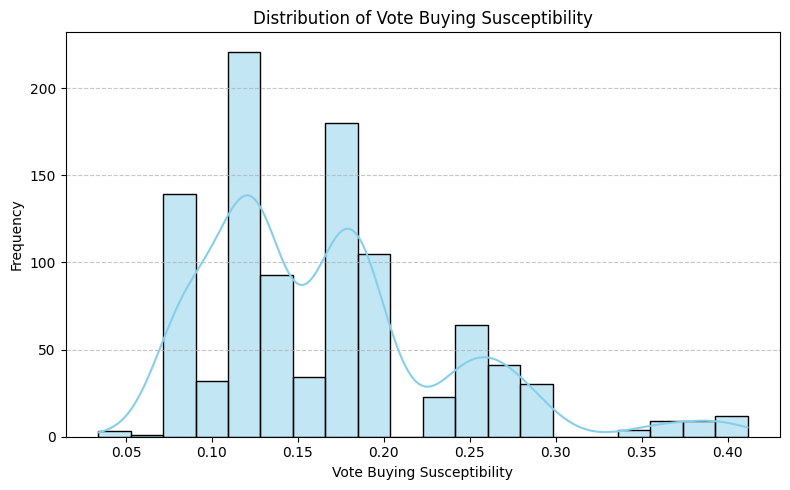


5 out of 5 candidates engaged in vote buying.


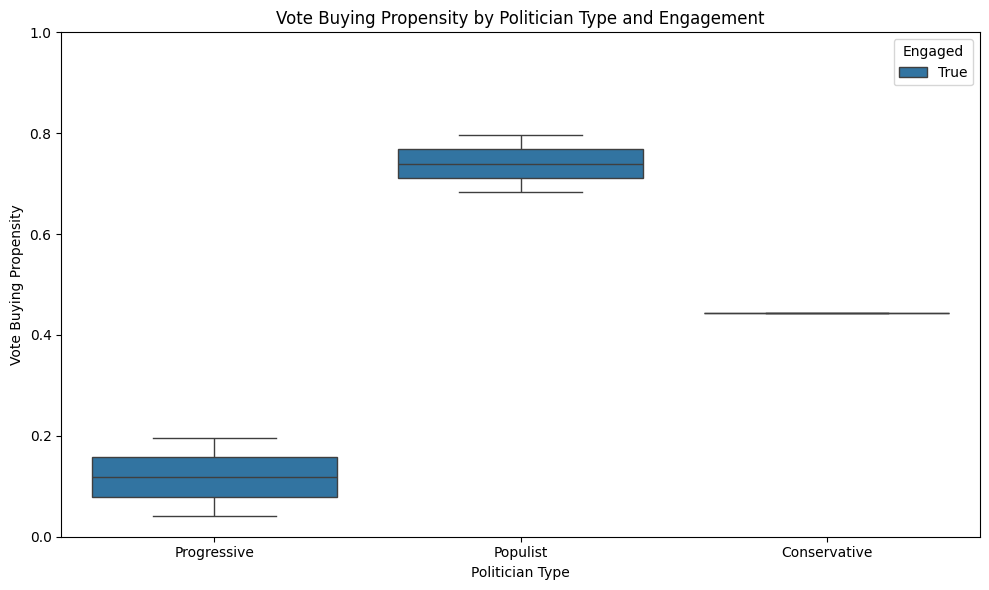

In [92]:
def plot_demographic_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    demo_data = [{'region': v.region, 'gender': v.gender, 'age_group': v.age_group, 'educ_attainment': v.educ_attainment, 'income_group': v.income_group, 'split': v.split} for v in voters]
    voter_df = pd.DataFrame(demo_data); demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns); ncols = 2; nrows = (num_plots + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)
    for i, col in enumerate(demographic_columns):
        ax = axes[i]; order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis'); ax.set_title(f'Distribution by {col.replace("_", " ").title()}'); ax.set_xlabel('Number of Voters'); ax.set_ylabel(col.replace("_", " ").title())
        for container in ax.containers: ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()

def plot_issue_stance_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    stance_data = [voter.issue_stances for voter in voters if hasattr(voter, 'issue_stances')]
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); issues = stance_df.columns; num_issues = len(issues)
    ncols = 2; nrows = (num_issues + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Issue Stances', fontsize=16, y=1.01)
    for i, issue in enumerate(issues):
        ax = axes[i]; sns.histplot(data=stance_df, x=issue, ax=ax, kde=True, bins=20); ax.set_title(f'Stance on {issue.replace("_", " ").title()}'); ax.set_xlabel('Stance (User Defined 0-1 Scale)'); ax.set_ylabel('Number of Voters'); ax.set_xlim(0, 1)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.99]); plt.show()

def plot_candidate_issue_stances(model):
    # (Keep function as before)
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)];
    if not candidates: print("No candidate agents found."); return
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            stance_entry = cand.issue_stances.copy(); stance_entry['CandidateID'] = cand.unique_id; stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown')
            stance_data.append(stance_entry)
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1); stance_df = stance_df.set_index('Label')
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float)
    plt.figure(figsize=(10, 8)); sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1); plt.title('Candidate Issue Stances (User Defined 0-1 Scale)'); plt.xlabel('Issue Area'); plt.ylabel('Candidate (Type)'); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

def plot_stances_by_demographic(model, demographic_column, plot_type='box'):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    data_list = []
    for voter in voters:
        if hasattr(voter, 'issue_stances') and hasattr(voter, demographic_column):
            demo_value = getattr(voter, demographic_column)
            for issue, stance in voter.issue_stances.items(): data_list.append({'VoterID': voter.unique_id, demographic_column: demo_value, 'Issue': issue, 'Stance': stance})
    if not data_list: print(f"No stance or demographic data for '{demographic_column}'."); return
    stance_df = pd.DataFrame(data_list); categories = sorted(stance_df[demographic_column].unique())
    if demographic_column == 'age_group':
        age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']; categories = [cat for cat in age_order if cat in categories]
    elif demographic_column == 'income_group':
        income_order = ['poverty', 'low', 'middle', 'high']; categories = [cat for cat in income_order if cat in categories]
    elif demographic_column == 'educ_attainment':
        edu_order = ['no_edu', 'early_child', 'elem', 'hs', 'post_sec', 'short_tert', 'college', 'post_bac']; categories = [cat for cat in edu_order if cat in categories]
    print(f"\nVisualizing Issue Stances by {demographic_column.replace('_', ' ').title()}...")
    plot_kind = plot_type if plot_type in ['box', 'violin'] else 'box'
    g = sns.catplot(data=stance_df, x=demographic_column, y='Stance', col='Issue', kind=plot_kind, col_wrap=3, sharey=True, height=4, aspect=1.2, order=categories, palette='viridis', legend=False)
    g.fig.suptitle(f'Voter Issue Stances by {demographic_column.replace("_", " ").title()}', y=1.03, fontsize=16)
    g.set_axis_labels(demographic_column.replace("_", " ").title(), "Stance (User Defined 0-1 Scale)"); g.set_titles("Issue: {col_name}"); g.set(ylim=(0, 1))
    for ax in g.axes.flatten(): ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_voter_evaluation_scores(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]; candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates: print("No voters or candidates found."); return
    plot_data = []; first_choice_scores = defaultdict(list)
    for voter in voters:
        if not voter.ranked_vote: continue
        first_choice_candidate = voter.ranked_vote[0]
        for cand_id, score in voter.approval_scores.items():
            plot_data.append({'CandidateID': cand_id, 'EvaluationScore': score})
            if cand_id == first_choice_candidate.unique_id: first_choice_scores[cand_id].append(score)
    if not plot_data: print("No evaluation scores found."); return
    eval_df = pd.DataFrame(plot_data); avg_first_choice_scores = {cand_id: np.mean(scores) if scores else 0 for cand_id, scores in first_choice_scores.items()}
    avg_plot_data = []; candidate_order = sorted([c.unique_id for c in candidates])
    for cand_id in candidate_order:
         if cand_id in avg_first_choice_scores: avg_plot_data.append({'CandidateID': cand_id, 'AverageScore': avg_first_choice_scores[cand_id]})
    avg_df = pd.DataFrame(avg_plot_data)
    plt.figure(figsize=(14, 7)); sns.boxplot(data=eval_df, x='CandidateID', y='EvaluationScore', order=candidate_order, palette='viridis', showfliers=False)
    if not avg_df.empty: sns.stripplot(data=avg_df, x='CandidateID', y='AverageScore', order=candidate_order, marker='D', s=10, color='red', label='Avg Score from 1st Pref Voters', jitter=False)
    plt.title('Distribution of Voter Evaluation Scores per Candidate'); plt.xlabel('Candidate ID'); plt.ylabel('Issue-Based Evaluation Score (0-1)'); plt.ylim(-0.05, 1.05); plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.legend(loc='best'); plt.tight_layout(); plt.show()

def plot_turnout_by_demographic(model):
    """
    Calculates and plots the voter turnout percentage for various demographic groups
    based on the simulation results.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have demographic attributes and the 'will_vote' attribute.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Check if the turnout simulation has likely run (i.e., will_vote exists)
    # Check the first voter, assuming all voters will have the attribute if one does after step()
    if not hasattr(voters[0], 'will_vote'):
        print("Warning: Voter agents do not have the 'will_vote' attribute.")
        print("Please ensure model.step() has been run before calling this function.")
        return # Return if attribute is missing


    # --- Collect Data ---
    demographic_data = []
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']

    for voter in voters:
        # Initialize data_entry for each voter
        data_entry = {'will_vote': getattr(voter, 'will_vote', False)} # Default to False if missing
        valid_entry = True
        for col in demographic_columns:
            if hasattr(voter, col):
                data_entry[col] = getattr(voter, col)
            else:
                # Print warning only once per missing attribute type for brevity
                if not hasattr(plot_turnout_by_demographic, f"warned_{col}"):
                     print(f"Warning: At least one voter missing demographic attribute '{col}'. Voters without it will be skipped for this plot.")
                     setattr(plot_turnout_by_demographic, f"warned_{col}", True)
                valid_entry = False
                break # Skip this voter if any demographic is missing
        if valid_entry:
            # Ensure all expected keys are present before appending
            if all(key in data_entry for key in demographic_columns + ['will_vote']):
                 demographic_data.append(data_entry)

    # Reset warnings for next call
    for col in demographic_columns:
         if hasattr(plot_turnout_by_demographic, f"warned_{col}"):
             delattr(plot_turnout_by_demographic, f"warned_{col}")


    if not demographic_data:
        print("No valid voter data with demographics and turnout status found.")
        return

    voter_df = pd.DataFrame(demographic_data)
    # Convert will_vote to integer (1 for True, 0 for False) for mean calculation
    voter_df['will_vote'] = voter_df['will_vote'].astype(int)


    # --- Plotting ---
    print("\nPlotting Simulated Voter Turnout Rate by Demographic Group...")

    num_plots = len(demographic_columns)
    ncols = 2
    nrows = (num_plots + ncols - 1) // ncols # Calculate necessary rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() # Flatten the axes array for easy iteration

    fig.suptitle('Simulated Voter Turnout Rate by Demographic Group', fontsize=18, y=1.03)

    for i, col in enumerate(demographic_columns):
        ax = axes[i]

        # Calculate turnout percentage for each category in the demographic column
        # Check if column exists and has data before grouping
        if col not in voter_df.columns or voter_df[col].isnull().all():
             print(f"Skipping plot for '{col}' due to missing data.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Data)')
             ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue # Skip to the next plot if no data for this column

        # Ensure the grouping column is treated as categorical for correct grouping
        voter_df[col] = voter_df[col].astype('category')

        turnout_rates = voter_df.groupby(col, observed=False)['will_vote'].mean() * 100 # Use observed=False
        turnout_rates = turnout_rates.sort_values(ascending=False) # Sort for better visualization

        # Define order for specific categorical plots if needed
        order = turnout_rates.index
        # Define known order for specific demographics
        if col == 'age_group':
            age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
            order = pd.Categorical(voter_df[col].unique(), categories=age_order, ordered=True)
            order = order.dropna().sort_values() # Use only categories present in the data, sorted correctly
            # Recalculate turnout rates with the correct order if needed (or pass order to sns.barplot)
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'income_group':
            income_order = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
            order = pd.Categorical(voter_df[col].unique(), categories=income_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'educ_attainment':
            edu_order = ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']
            order = pd.Categorical(voter_df[col].unique(), categories=edu_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()
        else:
             # For others like region, gender, split, sorted by rate is fine
             order = turnout_rates.index


        # Check if there are any rates to plot after potential filtering/reindexing
        if turnout_rates.empty:
             print(f"Skipping plot for '{col}' as no turnout rates could be calculated.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Rates)')
             ax.text(0.5, 0.5, 'No Rates Calculated', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue


        # Create the bar plot
        sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')

        # Add percentage labels to the bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=9)

        # Set titles and labels
        ax.set_title(f'Turnout by {col.replace("_", " ").title()}')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Turnout Rate (%)')
        ax.set_ylim(0, 100) # Y-axis from 0% to 100%

        # --- CORRECTED LINE ---
        # Set rotation and alignment for x-tick labels using plt.setp
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.show()

def plot_vote_buying_effect(model):
    """
    Visualizes the change in evaluation scores due to vote buying,
    faceted by candidate vote buying propensity.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have 'initial_approval_scores' and 'approval_scores'.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    # Check if necessary score attributes exist on the first voter (as a proxy)
    if not hasattr(voters[0], 'initial_approval_scores') or not hasattr(voters[0], 'approval_scores'):
        print("Warning: Score attributes ('initial_approval_scores' or 'approval_scores') not found.")
        print("Ensure VoterAgent.step stores both initial and final scores. Run model.step() first.")
        return

    plot_data = []
    for voter in voters:
        # Ensure scores were calculated for this specific voter
        initial_scores_dict = getattr(voter, 'initial_approval_scores', None)
        final_scores_dict = getattr(voter, 'approval_scores', None)
        if not initial_scores_dict or not final_scores_dict:
            continue # Skip voter if scores are missing

        for cand in candidates:
            cand_id = cand.unique_id
            initial_score = initial_scores_dict.get(cand_id, None)
            final_score = final_scores_dict.get(cand_id, None)
            propensity = getattr(cand, 'vote_buying_propensity', 0.0) # Get candidate propensity

            if initial_score is not None and final_score is not None:
                score_change = final_score - initial_score
                # Include only data points where a score increase occurred
                if score_change > 1e-6: # Use tolerance for floating point comparison
                     plot_data.append({
                         'VoterSusceptibility': getattr(voter, 'vote_buying_susceptibility', 0.0),
                         'CandidatePropensity': propensity,
                         'ScoreChange': score_change
                     })

    if not plot_data:
        print("No score changes due to vote buying were recorded or data is missing.")
        print("(This might be expected if no vote buying offers were accepted in the simulation step)")
        return

    effect_df = pd.DataFrame(plot_data)

    # --- Plotting Score Change Distribution ---
    print("\nPlotting Distribution of Score Changes Due to Vote Buying...")

    # Bin candidate propensity for faceting/hue
    propensity_bins = [-0.01, 0.3, 0.6, 1.0] # Bins: Low(0-0.3], Medium(0.3-0.6], High(0.6-1.0]
    propensity_labels = ['Low Propensity (0-0.3)', 'Medium Propensity (0.3-0.6)', 'High Propensity (0.6-1.0)']
    # Use right=True to include the right edge (e.g., 0.3 is in Low)
    effect_df['PropensityCategory'] = pd.cut(effect_df['CandidatePropensity'],
                                             bins=propensity_bins, labels=propensity_labels,
                                             right=True)

    # Check if any categories ended up empty after filtering score_change > 0
    if effect_df['PropensityCategory'].isnull().all():
        print("Warning: Could not categorize candidate propensities for plotting.")
        # Fallback: Plot without faceting if categorization fails
        plt.figure(figsize=(8, 5))
        sns.histplot(data=effect_df, x='ScoreChange', kde=False, bins=15)
        plt.title('Distribution of Score Increase Due to Vote Buying (All Candidates)')
        plt.xlabel("Score Increase (Final - Initial)")
        plt.ylabel("Number of Occurrences")
    else:
        # Histogram of score changes, faceted by candidate propensity category
        g = sns.displot(data=effect_df, x='ScoreChange', col='PropensityCategory',
                        kind='hist', kde=False, height=4, aspect=1.2, bins=15,
                        col_order=propensity_labels) # Ensure correct order

        g.fig.suptitle('Distribution of Evaluation Score Increase Due to Accepted Vote Buying Offers', y=1.03)
        g.set_axis_labels("Score Increase (Final - Initial)", "Number of Occurrences")
        g.set_titles("Candidate Propensity: {col_name}")

    # Set x-axis limits to focus around 0 and the boost value (e.g., 0.3)
    max_change = effect_df['ScoreChange'].max() if not effect_df.empty else 0.4
    plt.xlim(-0.05, max(0.4, max_change + 0.05)) # Ensure x-axis covers at least 0 to 0.4

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

def analyze_vote_buying_impact(model):
    """
    Analyze the impact of vote buying on the election results.
    
    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
    """
    # Extract VoterAgents from the model
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voter or candidate agents found in the model.")
        return

    # Gather data on vote buying susceptibility
    susceptibility_data = []
    for voter in voters:
        if hasattr(voter, "vote_buying_susceptibility"):
            susceptibility_data.append(voter.vote_buying_susceptibility)

    # Plot distribution of vote buying susceptibility
    plt.figure(figsize=(8, 5))
    sns.histplot(susceptibility_data, kde=True, bins=20, color="skyblue")
    plt.title("Distribution of Vote Buying Susceptibility")
    plt.xlabel("Vote Buying Susceptibility")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Analyze candidates who engaged in vote buying
    engaged_candidates = [c for c in candidates if getattr(c, 'engaged_in_vote_buying', False)]
    print(f"\n{len(engaged_candidates)} out of {len(candidates)} candidates engaged in vote buying.")

    if engaged_candidates:
        # Prepare data for plotting
        vote_buying_data = []
        for candidate in candidates:
            vote_buying_data.append({
                'CandidateID': candidate.unique_id,
                'Type': candidate.politician_type,
                'Propensity': candidate.vote_buying_propensity,
                'Engaged': getattr(candidate, 'engaged_in_vote_buying', False)
            })
            
        vote_buying_df = pd.DataFrame(vote_buying_data)
        
        # Plot propensity by type with engagement status
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Type', y='Propensity', hue='Engaged', data=vote_buying_df)
        plt.title('Vote Buying Propensity by Politician Type and Engagement')
        plt.xlabel('Politician Type')
        plt.ylabel('Vote Buying Propensity')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

    else:
        print("No candidates engaged in vote buying in this simulation run.")

import matplotlib.pyplot as plt
import seaborn as sns

# Run the model and analyze vote buying impact
model = ElectionModel(num_voters=1000, num_candidates=5)
model.step()
analyze_vote_buying_impact(model)


# Evaluations

## Helper Functions

In [93]:
def calculate_voter_satisfaction(model, winner):
    """
    Calculate the average voter satisfaction for a given winner in the model.
    
    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.
    
    Returns:
        float: The average satisfaction score of voters who turned out.
    """
    if not winner:
        return None  # No winner, no satisfaction to calculate
    
    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent) and v.will_vote]
    if not voters:
        return None  # No voters turned out
    
    # Calculate satisfaction for each voter
    satisfaction_scores = [voter.get_issue_score(winner) for voter in voters]
    
    # Return the average satisfaction score
    return np.mean(satisfaction_scores) if satisfaction_scores else None

In [94]:
def calculate_issue_representation_distance(model, winner):
    """
    Calculate the distance between the winner's issue stances and the average voter stance.

    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.

    Returns:
        float: The weighted Euclidean distance between the winner's stance and the average voter stance.
    """
    if not winner:
        return None  # No winner, no distance to calculate

    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent)]
    if not voters:
        return None  # No voters in the model

    # Calculate average voter stance and priority
    total_stances = defaultdict(float)
    total_priorities = defaultdict(float)
    total_voters = 0

    for voter in voters:
        if not hasattr(voter, 'issue_stances') or not hasattr(voter, 'issue_priorities'):
            continue  # Skip voters without stances or priorities

        for issue, stance in voter.issue_stances.items():
            total_stances[issue] += stance
        for issue, priority in voter.issue_priorities.items():
            total_priorities[issue] += priority

        total_voters += 1

    if total_voters == 0:
        return None  # No valid voters

    # Compute average stances and priorities
    avg_stances = {issue: total / total_voters for issue, total in total_stances.items()}
    avg_priorities = {issue: total / total_voters for issue, total in total_priorities.items()}

    # Calculate weighted Euclidean distance between winner's stances and average voter stances
    distance = 0.0
    for issue, avg_stance in avg_stances.items():
        winner_stance = winner.issue_stances.get(issue, 0.5)  # Default to neutral stance if missing
        weight = avg_priorities.get(issue, 1.0)  # Default to equal weight if missing
        distance += weight * (winner_stance - avg_stance) ** 2

    return distance ** 0.5  # Return the square root of the sum of squared differences

## Evaluation Functions

In [95]:
from mesa.batchrunner import batch_run

# Define the parameters for the batch run
parameters = {
    "num_voters": [1000],
    "num_candidates": [5],
    "influence": np.arange(0, 2.5, 0.5),  # Changed from vote_buy_boost to influence
}

# Run batch simulations
results = batch_run(
    ElectionModel,
    parameters=parameters,
    iterations=5,
    max_steps=1,
    data_collection_period=-1,
    display_progress=True,
)

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

  0%|          | 0/25 [00:00<?, ?it/s]

In [96]:
# Drop Rows with NaN Values
results_df.dropna(inplace=True)
# Reset Index
results_df.reset_index(drop=True, inplace=True)
results_df.columns

Index(['RunId', 'iteration', 'Step', 'num_voters', 'num_candidates',
       'influence', 'Turnout Percentage', 'Plurality Winner', 'IRV Winner',
       'Approval Winner', 'Borda Winner', 'Condorcet Winner', 'Borda Scores',
       'Plurality Satisfaction', 'IRV Satisfaction', 'Approval Satisfaction',
       'Borda Satisfaction', 'Condorcet Satisfaction', 'Plurality Distance',
       'IRV Distance', 'Approval Distance', 'Borda Distance',
       'Condorcet Distance', 'Avg Vote Buying Susceptibility', 'AgentID',
       'Candidate Type', 'Candidate Propensity',
       'Candidate Engaged in Vote Buying'],
      dtype='object')

In [97]:
# Save the results to a CSV file
results_df.to_csv("batch_simulation_results_vote_buying_only.csv", index=False)

In [98]:
print("\n=== Simulation Results ===")
print(f"Total Runs: {len(results_df)}")
print(f"Average Turnout Rate: {results_df['Turnout Percentage'].mean():.2f}%")
    
# Updated Results Analysis
print("\n=== Winner Frequency Analysis ===")

# Analyze winners by vote buying characteristics
methods = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
for method in methods:
    col = f'{method} Winner'
    if results_df[col].notna().any():
        print(f"\n{method.upper()} WINNERS BY CHARACTERISTICS:")
        
        # Collect characteristics of winners
        characteristics = {
            "Engaged in Vote Buying": 0,
            "Did Not Vote Buy": 0,
            "Populist": 0,
            "Liberal": 0,
            "Conservative": 0,
            "Progressive": 0
        }
        
        # Iterate through winners and categorize
        for winner_id in results_df[col].dropna():
            winner = next((c for c in model.schedule.agents if isinstance(c, CandidateAgent) and c.unique_id == winner_id), None)
            if winner:
                # Vote buying engagement
                if winner.engaged_in_vote_buying:
                    characteristics["Engaged in Vote Buying"] += 1
                else:
                    characteristics["Did Not Vote Buy"] += 1
                
                # Archetype
                archetype = winner.politician_type
                if archetype in characteristics:
                    characteristics[archetype] += 1
        
        # Display results
        total_winners = len(results_df[col].dropna())
        for char, count in characteristics.items():
            percentage = (count / total_winners) * 100 if total_winners > 0 else 0
            print(f"  {char}: {count}/{total_winners} ({percentage:.1f}%)")


=== Simulation Results ===
Total Runs: 125
Average Turnout Rate: 83.22%

=== Winner Frequency Analysis ===

PLURALITY WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 125/125 (100.0%)
  Did Not Vote Buy: 0/125 (0.0%)
  Populist: 40/125 (32.0%)
  Liberal: 0/125 (0.0%)
  Conservative: 20/125 (16.0%)
  Progressive: 65/125 (52.0%)

IRV WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 125/125 (100.0%)
  Did Not Vote Buy: 0/125 (0.0%)
  Populist: 45/125 (36.0%)
  Liberal: 0/125 (0.0%)
  Conservative: 15/125 (12.0%)
  Progressive: 65/125 (52.0%)

APPROVAL WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 125/125 (100.0%)
  Did Not Vote Buy: 0/125 (0.0%)
  Populist: 45/125 (36.0%)
  Liberal: 0/125 (0.0%)
  Conservative: 15/125 (12.0%)
  Progressive: 65/125 (52.0%)

BORDA WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 125/125 (100.0%)
  Did Not Vote Buy: 0/125 (0.0%)
  Populist: 45/125 (36.0%)
  Liberal: 0/125 (0.0%)
  Conservative: 15/125 (12.0%)
  Progressive: 65/125 (52

In [99]:
def calculate_winner_agreement(results_df):
    """
    Calculate how often different pairs of voting systems produce the same winner.

    Args:
        results_df (pd.DataFrame): DataFrame containing the results of the simulation runs.

    Returns:
        pd.DataFrame: A DataFrame showing the agreement percentages for each pair of voting systems.
    """
    methods = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    agreement_counts = {}

    # Iterate through all pairs of methods
    for i, method1 in enumerate(methods):
        for method2 in methods[i + 1:]:
            # Count how often the winners match
            matches = (results_df[method1] == results_df[method2]).sum()
            total_runs = len(results_df)
            agreement_percentage = (matches / total_runs) * 100
            agreement_counts[(method1, method2)] = agreement_percentage

    # Convert to a DataFrame for better visualization
    agreement_df = pd.DataFrame([
        {'Method 1': m1, 'Method 2': m2, 'Agreement (%)': agreement_counts[(m1, m2)]}
        for m1, m2 in agreement_counts
    ])

    return agreement_df

# Perform the analysis
agreement_df = calculate_winner_agreement(results_df)

# Display the results
print("\n=== Winner Agreement Analysis ===")
print(agreement_df)


=== Winner Agreement Analysis ===
           Method 1          Method 2  Agreement (%)
0  Plurality Winner        IRV Winner           96.0
1  Plurality Winner   Approval Winner           96.0
2  Plurality Winner      Borda Winner           80.0
3  Plurality Winner  Condorcet Winner           96.0
4        IRV Winner   Approval Winner          100.0
5        IRV Winner      Borda Winner           84.0
6        IRV Winner  Condorcet Winner          100.0
7   Approval Winner      Borda Winner           84.0
8   Approval Winner  Condorcet Winner          100.0
9      Borda Winner  Condorcet Winner           84.0


In [100]:
def analyze_utilitarian_efficiency(results_df):
    """Analyze the average Borda score of the winners for each voting system."""
    methods = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    efficiency_results = {}

    for method in methods:
        total_borda_score = 0
        count = 0

        for _, row in results_df.iterrows():
            winner_id = row[method]
            if winner_id and row['Borda Scores']:
                total_borda_score += row['Borda Scores'].get(winner_id, 0)
                count += 1

        if count > 0:
            efficiency_results[method] = total_borda_score / count
        else:
            efficiency_results[method] = None

    return efficiency_results


# Perform the analysis
efficiency_results = analyze_utilitarian_efficiency(results_df)

# Display the results
print("\n=== Utilitarian Efficiency Analysis ===")
for method, avg_borda_score in efficiency_results.items():
    print(f"{method.replace('_winner', '').title()}: Average Borda Score = {avg_borda_score:.2f}" if avg_borda_score is not None else f"{method.replace('_winner', '').title()} Winner: No Data")


=== Utilitarian Efficiency Analysis ===
Plurality Winner: Average Borda Score = 2455.60
Irv Winner: Average Borda Score = 2480.24
Approval Winner: Average Borda Score = 2480.24
Borda Winner: Average Borda Score = 2485.56
Condorcet Winner: Average Borda Score = 2480.24


In [101]:
# Calculate overall average satisfaction for each voting system
print("\n=== Issue Representation (Average Voter Satisfaction) ===")
satisfaction_columns = [
    'Plurality Satisfaction',
    'IRV Satisfaction',
    'Approval Satisfaction',
    'Borda Satisfaction',
    'Condorcet Satisfaction',
]

for col in satisfaction_columns:
    avg_satisfaction = results_df[col].mean()
    print(f"{col.replace('_satisfaction', '').title()} Winner: Average Satisfaction = {avg_satisfaction:.4f}")


=== Issue Representation (Average Voter Satisfaction) ===
Plurality Satisfaction Winner: Average Satisfaction = 0.7438
Irv Satisfaction Winner: Average Satisfaction = 0.7443
Approval Satisfaction Winner: Average Satisfaction = 0.7443
Borda Satisfaction Winner: Average Satisfaction = 0.7431
Condorcet Satisfaction Winner: Average Satisfaction = 0.7443


In [103]:
print("\n=== Issue Representation Distance Analysis ===")
distance_columns = [
    'Plurality Distance',
    'IRV Distance',
    'Approval Distance',
    'Borda Distance',
    'Condorcet Distance',
]

for col in distance_columns:
    avg_distance = results_df[col].mean()
    print(f"{col.replace('_distance', '').title()} Winner: Average Distance = {avg_distance:.4f}")


=== Issue Representation Distance Analysis ===
Plurality Distance Winner: Average Distance = 0.2228
Irv Distance Winner: Average Distance = 0.2219
Approval Distance Winner: Average Distance = 0.2219
Borda Distance Winner: Average Distance = 0.2240
Condorcet Distance Winner: Average Distance = 0.2219


C:\Users\ajalv\AppData\Local\Temp\ipykernel_10016\1758787045.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vote_buying_analysis = results_df.groupby('influence').apply(lambda x: pd.Series({  # Changed from vote_buy_boost to influence


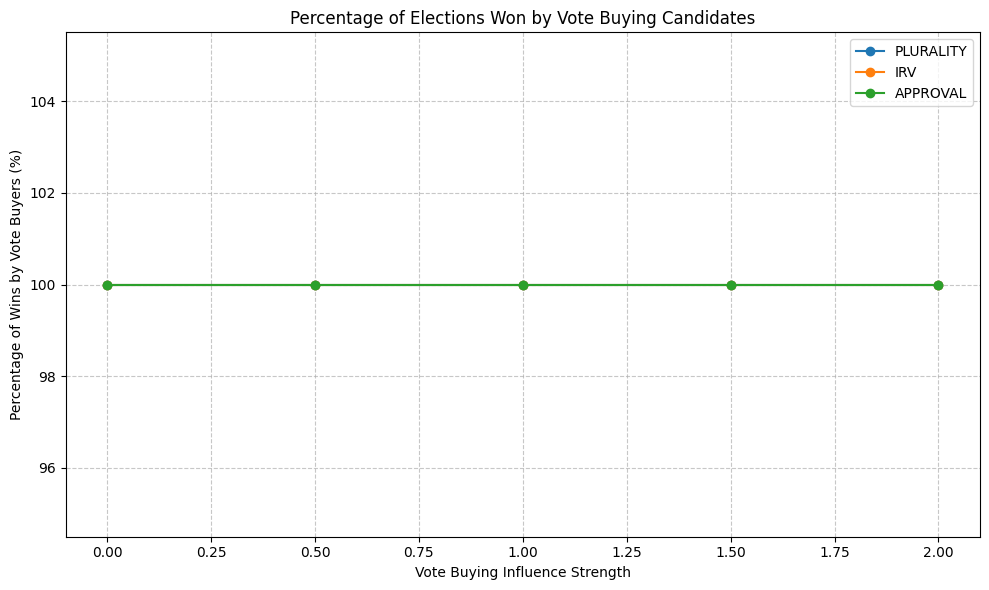

In [104]:
# Plot relationship between vote buying influence and winner characteristics
vote_buying_analysis = results_df.groupby('influence').apply(lambda x: pd.Series({  # Changed from vote_buy_boost to influence
    'vote_buyers_won_plurality': sum(x['Plurality Winner'].apply(lambda w: next((c.engaged_in_vote_buying for c in model.schedule.agents if isinstance(c, CandidateAgent) and c.unique_id == w), False))),
    'vote_buyers_won_irv': sum(x['IRV Winner'].apply(lambda w: next((c.engaged_in_vote_buying for c in model.schedule.agents if isinstance(c, CandidateAgent) and c.unique_id == w), False))),
    'vote_buyers_won_approval': sum(x['Approval Winner'].apply(lambda w: next((c.engaged_in_vote_buying for c in model.schedule.agents if isinstance(c, CandidateAgent) and c.unique_id == w), False))),
    'runs': len(x)
})).reset_index()

# Calculate percentages
for method in ['plurality', 'irv', 'approval']:
    vote_buying_analysis[f'{method}_pct'] = vote_buying_analysis[f'vote_buyers_won_{method}'] / vote_buying_analysis['runs'] * 100

# Plot the results
plt.figure(figsize=(10, 6))
for method in ['plurality', 'irv', 'approval']:
    plt.plot(vote_buying_analysis['influence'], vote_buying_analysis[f'{method}_pct'], marker='o', label=method.upper())  # Changed from vote_buy_boost to influence

plt.title('Percentage of Elections Won by Vote Buying Candidates')
plt.xlabel('Vote Buying Influence Strength')  # Updated label
plt.ylabel('Percentage of Wins by Vote Buyers (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()